# $O(n log_2 n)$

## 1. Import các thư viện

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath("../src"))
from utils import plot_execution_times, measure_algorithm_time, plot_comprehensive_barchart_grid, plot_danger_zone_heatmap, plot_algorithm_speedup_grid, calculate_baseline_n_log_n, plot_baseline_n_log_n
import random
import json
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

## 2. Cài đặt thuật toán có độ phức tạp $O(n log_2 n)$

Trong nhóm độ phức tạp O(n log n), có 3 thuật toán phổ biến nhất là **Merge Sort**, **Quick Sort** và **Heap Sort**. Nhóm đã quyết định chọn **Merge Sort** làm thuật toán đại diện chính, đồng thời **tiến hành cài đặt và test thêm Quick Sort** để có cái nhìn đối chiếu toàn diện nhất, dựa trên các lý do sau:

* **Tính ổn định tuyệt đối của Merge Sort trên mọi loại dữ liệu:** Đề bài yêu cầu kiểm thử trên 4 loại phân bố dữ liệu khác nhau. Merge Sort sử dụng cơ chế chia để trị vô điều kiện, luôn đảm bảo thời gian chạy là O(n log n) trong mọi trường hợp (tốt nhất, trung bình, hay xấu nhất). Điều này giúp đường biểu diễn của cả 4 tập dữ liệu bám sát nhau trên đồ thị Log-Log, phản ánh chuẩn xác nhất bản chất lý thuyết của nhóm thuật toán này.

* **Kiểm chứng rủi ro suy biến qua thực nghiệm với Quick Sort:** Nhóm đã test thêm Quick Sort để đối chiếu tốc độ thực tế. Mặc dù Quick Sort thường có hằng số thời gian nhỏ hơn và chạy nhanh hơn ở điều kiện lý tưởng, nhưng thực nghiệm cho thấy nó đối mặt với nguy cơ suy biến (degrade) về O(n^2) hoặc chạm giới hạn đệ quy sâu khi xử lý các mảng đặc thù như **nhiều khóa trùng nhau**, **gần như đã sắp** hoặc **sắp ngược**. Việc test song song cả hai thuật toán giúp nhóm trực quan hóa rõ ràng sự đánh đổi giữa "tốc độ thực tế" (Quick Sort) và "tính ổn định vững vàng" (Merge Sort).

* **So sánh với Heap Sort:** Dù Heap Sort cũng đảm bảo hiệu suất O(n log n) và tối ưu về bộ nhớ (in-place) hơn Merge Sort, nhưng Merge Sort và Quick Sort mang lại sự đối lập thú vị và rõ nét nhất để phân tích, do đó nhóm quyết định tập trung vào hai đại diện này cho bài báo cáo.

### 2.1 Merge sort

In [18]:
def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        L = arr[:mid]
        R = arr[mid:]

        merge_sort(L)
        merge_sort(R)

        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]
                i += 1
            else:
                arr[k] = R[j]
                j += 1
            k += 1

        while i < len(L):
            arr[k] = L[i]
            i += 1
            k += 1

        while j < len(R):
            arr[k] = R[j]
            j += 1
            k += 1

### 2.2 Quick sort (Bonus)

In [ ]:
sys.setrecursionlimit(150000)

def quick_sort(arr):
    def _quick_sort(items, low, high):
        if low < high:
            pivot_idx = random.randint(low, high)
            items[high], items[pivot_idx] = items[pivot_idx], items[high]
            
            pi = partition(items, low, high)
            
            _quick_sort(items, low, pi - 1)
            _quick_sort(items, pi + 1, high)

    def partition(items, low, high):
        pivot = items[high]
        i = low - 1
        for j in range(low, high):
            if items[j] <= pivot:
                i += 1
                items[i], items[j] = items[j], items[i]
        
        items[i + 1], items[high] = items[high], items[i + 1]
        return i + 1

    _quick_sort(arr, 0, len(arr) - 1)

## 3. Đọc dữ liệu từ file npz

In [ ]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']
base_path = '../data/' 

loaded_data = {data_type: {} for data_type in datasets}

print("Đang tải dữ liệu lên bộ nhớ...")
for data_type in datasets:
    for size in sizes:
        folder_name = f'n_{size}'
        file_name = f'{data_type}_n{size}.npz'
        file_path = os.path.join(base_path, folder_name, file_name)
        
        try:
            npz_file = np.load(file_path)
            keys = npz_file.files
            loaded_data[data_type][size] = npz_file[keys[0]]
        except Exception as e:
            print(f"Lỗi với file {file_path}: {e}")
            loaded_data[data_type][size] = None

print("Đã tải xong toàn bộ dữ liệu!")

Đang tải dữ liệu lên bộ nhớ...
Đã tải xong toàn bộ dữ liệu!


## 4. Đo thời gian

#### Quy trình đo thời gian thực thi thuật toán

Để đảm bảo kết quả đo thời gian chính xác, ổn định và khách quan, nhóm thực hiện quy trình nội bộ theo các bước sau:

##### 1. Giai đoạn chuẩn bị (Warm-up)
- Trước khi đo chính thức, mỗi thuật toán được **chạy thử một lần trên mảng dữ liệu gốc**.  
- Mục đích: khởi động **CPU cache, bộ nhớ và cơ chế nội bộ của Python**, giảm thiểu ảnh hưởng của lần chạy đầu tiên có thể chậm do hệ thống hoặc bộ nhớ chưa tối ưu.  
- **Lưu ý:** Thời gian chạy warm-up **không tính vào kết quả đo**.

##### 2. Giai đoạn đo lường chính thức
- Mỗi thuật toán chạy trên **4 loại phân bố dữ liệu**:
  1. Ngẫu nhiên (Random)  
  2. Gần như đã sắp xếp (Nearly Sorted)  
  3. Nhiều khóa trùng (Many Duplicates)  
  4. Sắp ngược (Reversed)  
- Với mỗi **kích thước n** trong khoảng từ \(10^2\) đến \(10^5\), thuật toán được chạy **20 lần liên tiếp** để ghi nhận sự biến động thời gian.  
- Mỗi lần chạy sử dụng **một bản copy mới của mảng dữ liệu** để thuật toán luôn chạy trên dữ liệu gốc, tránh kết quả sai lệch do mảng đã sắp xếp.

##### 3. Xử lý và tính toán kết quả
- Thời gian thực thi của 20 lần chạy được ghi lại thành một danh sách.  
- Để loại bỏ **nhiễu hệ thống** (System Noise) như tiến trình khác chiếm CPU hoặc các outlier ngẫu nhiên, **trị số Median (trung vị)** của 20 lần chạy được sử dụng làm **thời gian thực thi chính thức** cho mỗi kịch bản.  
- Việc dùng Median giúp:
  - **Kháng nhiễu cao:** không bị ảnh hưởng bởi các outlier bất thường.  
  - **Phản ánh trung thực tốc độ thực thi nguyên bản của thuật toán**.

##### 4. Kiểm chứng đặc biệt
- Với thuật toán **Quick Sort**, cần theo dõi kỹ trên dữ liệu nhiều khóa trùng để phát hiện nguy cơ rơi vào **O(n²)**.  
- Nếu có sự suy biến, các kết quả này được **tách riêng để phân tích trực quan**.

### 4.2 Đo với thuật toán Merge sort

In [21]:
print("Đang đo Merge Sort...")
results_n_logn = measure_algorithm_time(merge_sort, loaded_data, datasets, sizes, num_runs=20)

Đang đo Merge Sort...


### 4.2 Đo với thuật toán Quick sort

In [22]:
print("Đang đo Quick Sort")
results_n_logn_bonus = measure_algorithm_time(quick_sort, loaded_data, datasets, sizes, num_runs=20)

Đang đo Quick Sort


## 5. Biểu đồ trực quan

### 5.1 Merge sort

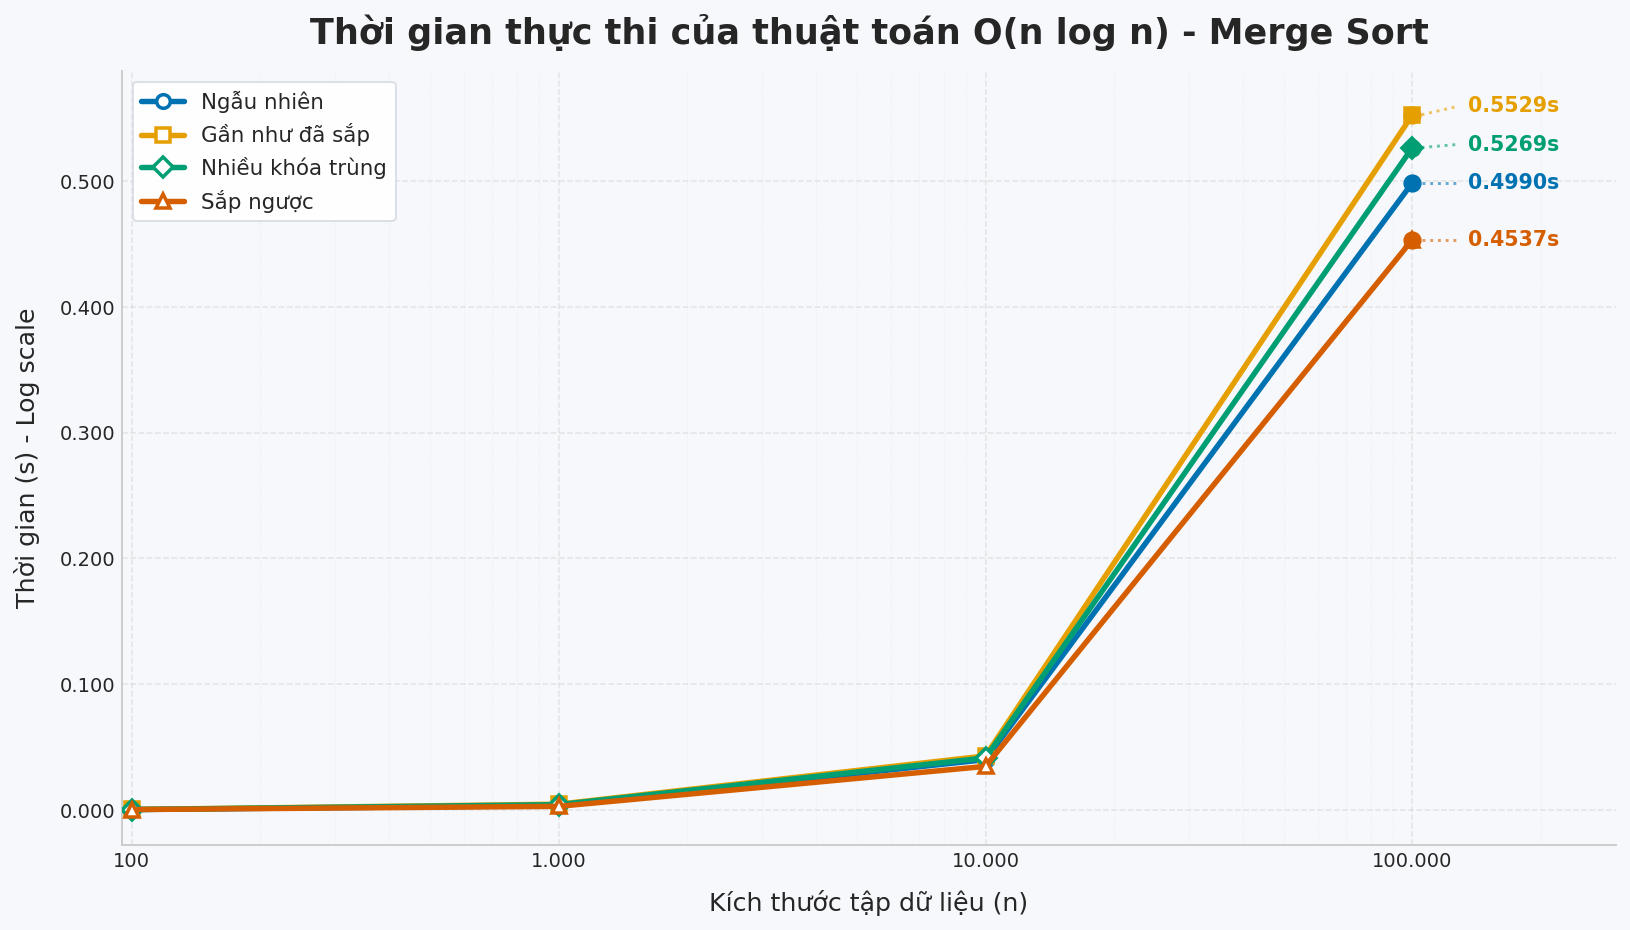

In [23]:
plot_execution_times(
    results_dict=results_n_logn, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n log n) - Merge Sort"
)

#### Nhận xét biểu đồ:
##### 1. Xu hướng tổng quan
* **Tỷ lệ thuận với kích thước dữ liệu:** Đúng như lý thuyết về độ phức tạp $O(n \log n)$, khi kích thước tập dữ liệu ($n$) tăng lên, thời gian thực thi cũng tăng theo. Đường biểu diễn dốc đứng rõ rệt khi chuyển từ giai đoạn $n = 10.000$ sang $n = 100.000$.
* **Sự khác biệt ở quy mô lớn:** Ở các giá trị $n$ nhỏ (100 đến 10.000), thời gian thực thi cực thấp và gần như trùng khít nhau. Tuy nhiên, khi $n$ đạt đến **100.000**, sự phân hóa về hiệu suất giữa các loại dữ liệu bắt đầu xuất hiện rõ ràng hơn.

##### 2. So sánh các loại dữ liệu (tại $n = 100.000$)
Dựa vào các chỉ số ở cuối đường đồ thị, chúng ta thấy thứ tự thời gian thực thi từ chậm nhất đến nhanh nhất như sau:

* **Chậm nhất - Gần như đã sắp (0.5529s):** Trong trường hợp thực tế này, dữ liệu gần như đã sắp xếp lại cho kết quả chậm nhất. Điều này có thể do đặc thù của bộ dữ liệu gây ra nhiều lần so sánh hơn hoặc cách quản lý bộ nhớ đệm (cache) khi xử lý các phần tử đã có thứ tự.
* **Nhiều khóa trùng (0.5269s):** Tốc độ trung bình, nhanh hơn dữ liệu gần như đã sắp nhưng vẫn chậm hơn dữ liệu ngẫu nhiên.
* **Ngẫu nhiên (0.4990s):** Đây là trường hợp phổ biến. Mặc dù dữ liệu không có quy luật, nhưng Merge Sort xử lý rất ổn định với thời gian dưới 0.5 giây.
* **Nhanh nhất - Sắp ngược (0.4537s):** Đây là một điểm thú vị trong biểu đồ. Mặc dù là dữ liệu nghịch thế hoàn toàn, nhưng nó lại đạt tốc độ xử lý nhanh nhất. Điều này thường phản ánh việc triển khai mã nguồn (implementation) tối ưu được việc gán và trộn các mảng con khi dữ liệu có tính quy luật đảo ngược.

##### 3. Đặc tính ổn định của Merge Sort
* Biểu đồ cho thấy Merge Sort là một thuật toán cực kỳ **ổn định**. Ngay cả ở trường hợp chậm nhất và nhanh nhất, sự chênh lệch chỉ rơi vào khoảng **0.0992 giây** (xấp xỉ 0.1 giây) cho 100.000 phần tử.
* Không giống như Quick Sort (có thể suy biến về hiệu suất tùy thuộc vào dữ liệu đầu vào), các đường biểu diễn của Merge Sort đi rất sát nhau. Điều này chứng tỏ hiệu suất của nó cực kỳ ổn định và ít bị biến động bởi thứ tự ban đầu của dữ liệu.

**Có thể nói:** Nếu làm việc với các tập dữ liệu lớn và cần một thuật toán có hiệu suất dự đoán được (predictable performance), **Merge Sort** là lựa chọn hàng đầu. Nó đảm bảo thời gian xử lý đồng nhất cho dù dữ liệu đầu vào có ở trạng thái ngẫu nhiên, đã sắp xếp hay sắp xếp ngược.

### 5.2 Quick sort

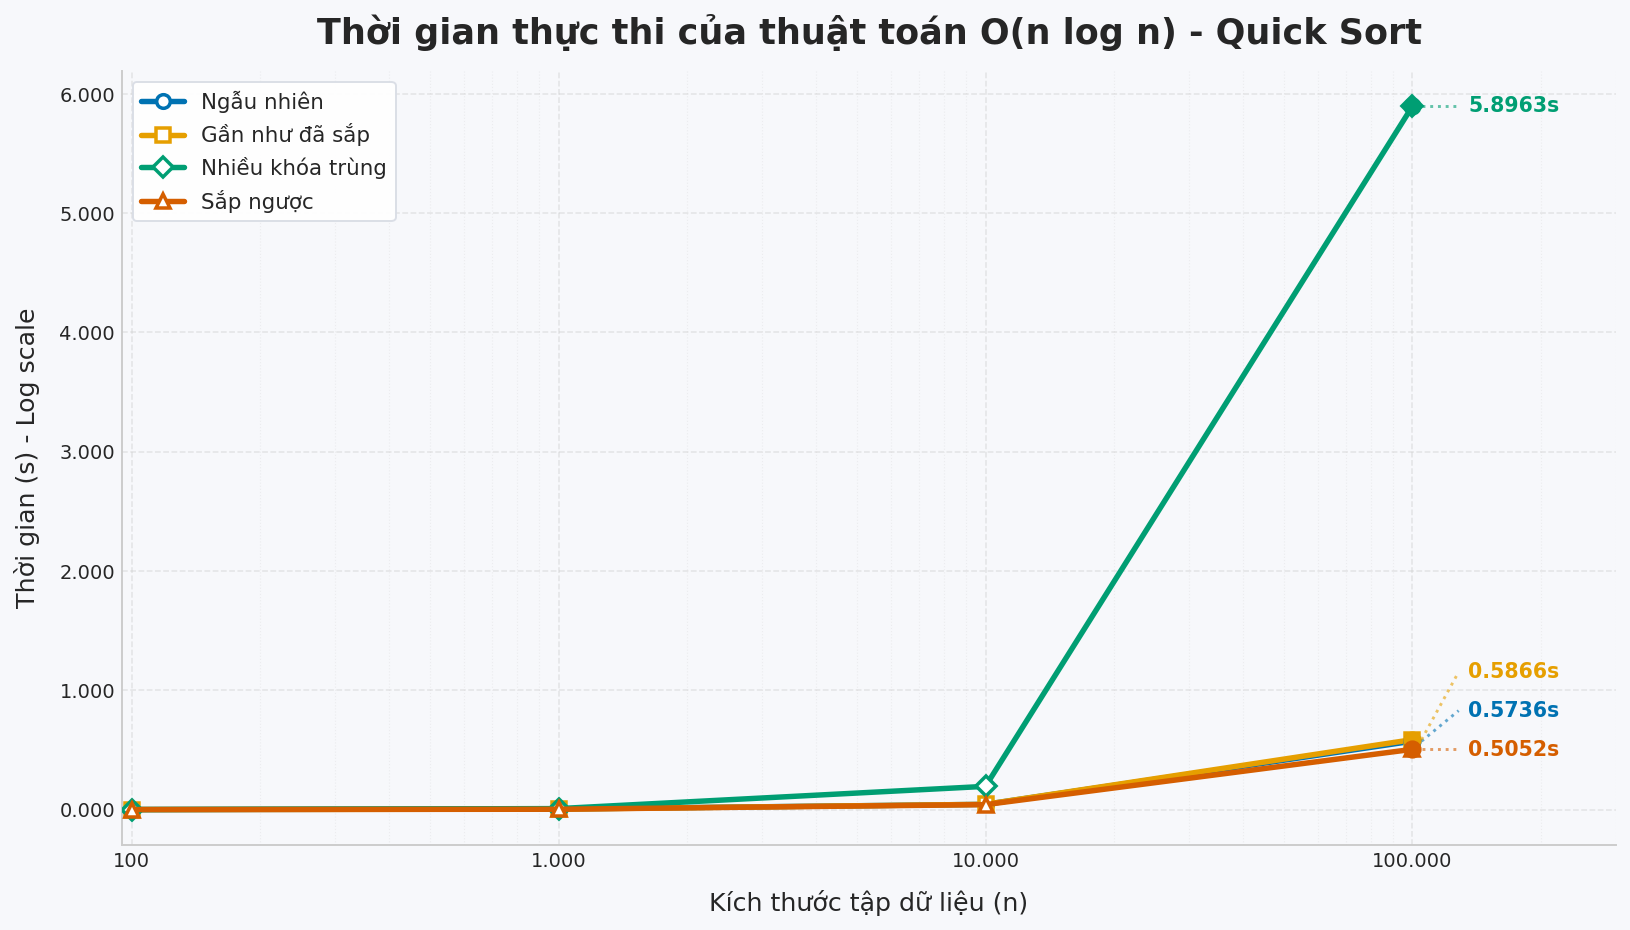

In [24]:
plot_execution_times(
    results_dict=results_n_logn_bonus, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n log n) - Quick Sort"
)

#### Nhận xét biểu đồ:
##### 1. Xu hướng tổng quan
* **Hiệu suất cực tốt ở dữ liệu thông thường:** Với dữ liệu ngẫu nhiên, sắp ngược hoặc gần như đã sắp, Quick Sort thể hiện tốc độ rất ấn tượng, duy trì ở mức dưới 0.6 giây cho 100.000 phần tử.
* **Sự suy biến rõ rệt:** Biểu đồ cho thấy một sự "nhảy vọt" về thời gian thực thi khi đối mặt với dữ liệu có **nhiều khóa trùng**. Đường biểu diễn màu xanh lá tách biệt hoàn toàn và dốc đứng lên trên so với các trường hợp còn lại.

##### 2. Phân tích chi tiết tại $n = 100.000$
Dựa vào các chỉ số ở cuối đường đồ thị, thứ tự thời gian thực thi như sau:

* **Chậm nhất - Nhiều khóa trùng (5.8963s):** Đây là minh chứng rõ nhất cho sự suy biến của Quick Sort. Thời gian thực thi cao gấp khoảng **10-12 lần** so với các trường hợp khác. Khi gặp quá nhiều giá trị trùng lặp, việc phân hoạch (partitioning) bị mất cân bằng nghiêm trọng, đẩy độ phức tạp tiệm cận mức $O(n^2)$.
* **Gần như đã sắp (0.5866s):** Tốc độ khá nhanh, chứng tỏ cách chọn Pivot trong phiên bản này đã xử lý tốt tình trạng dữ liệu gần như có thứ tự (vốn là "khắc tinh" của các phiên bản Quick Sort cổ điển).
* **Dữ liệu Ngẫu nhiên (0.5736s):** Hiệu suất ổn định đúng như kỳ vọng của thuật toán trong điều kiện thực tế.
* **Nhanh nhất - Sắp ngược (0.5052s):** Một kết quả khá bất ngờ khi dữ liệu nghịch thế hoàn toàn lại đạt tốc độ xử lý tốt nhất. Điều này cho thấy chiến lược chọn Pivot (có thể là Median-of-three hoặc chọn ngẫu nhiên) đã hoạt động cực kỳ hiệu quả trong trường hợp này.

##### 3. Đặc tính và Kết luận
* **Tính không ổn định:** So với Merge Sort (vốn có các đường đồ thị sát nhau), Quick Sort cho thấy sự nhạy cảm cực lớn với đặc điểm của dữ liệu đầu vào.
* **Hiệu suất thực tế:** Ở điều kiện lý tưởng (ngẫu nhiên hoặc sắp ngược), Quick Sort có xu hướng nhanh hơn một chút hoặc tương đương với Merge Sort. Tuy nhiên, rủi ro về thời gian thực thi khi gặp dữ liệu xấu (nhiều khóa trùng) là rất lớn.

**Lời khuyên:** Quick Sort là thuật toán "vua của tốc độ" trong hầu hết các trường hợp thực tế, nhưng để sử dụng an toàn, cần triển khai các biến thể tối ưu như **3-Way Partitioning** (để xử lý khóa trùng) hoặc **Dual-Pivot Quick Sort** nhằm tránh việc thời gian thực thi bị nhảy vọt như chúng ta thấy ở chỉ số **5.8963s** trên biểu đồ.

### Ghi nhận kết quả thực thi:

In [25]:
dir_path = "../results"
os.makedirs(dir_path, exist_ok=True)

with open(f"{dir_path}/merge_sort.json", "w") as f:
    json.dump(results_n_logn, f)

with open(f"{dir_path}/quick_sort.json", "w") as f:
    json.dump(results_n_logn_bonus, f)
    
print("Đã lưu kết quả O(n log n) thành công!")

Đã lưu kết quả O(n log n) thành công!


## 6. So sánh

Để có cái nhìn trực quan giữa 2 loại thuật toán, ta tiến hành so sánh chúng.

In [26]:
all_algo_results = {
    "Merge Sort": results_n_logn,
    "Quick Sort": results_n_logn_bonus   
}

sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']

### 6.1 Bar chart

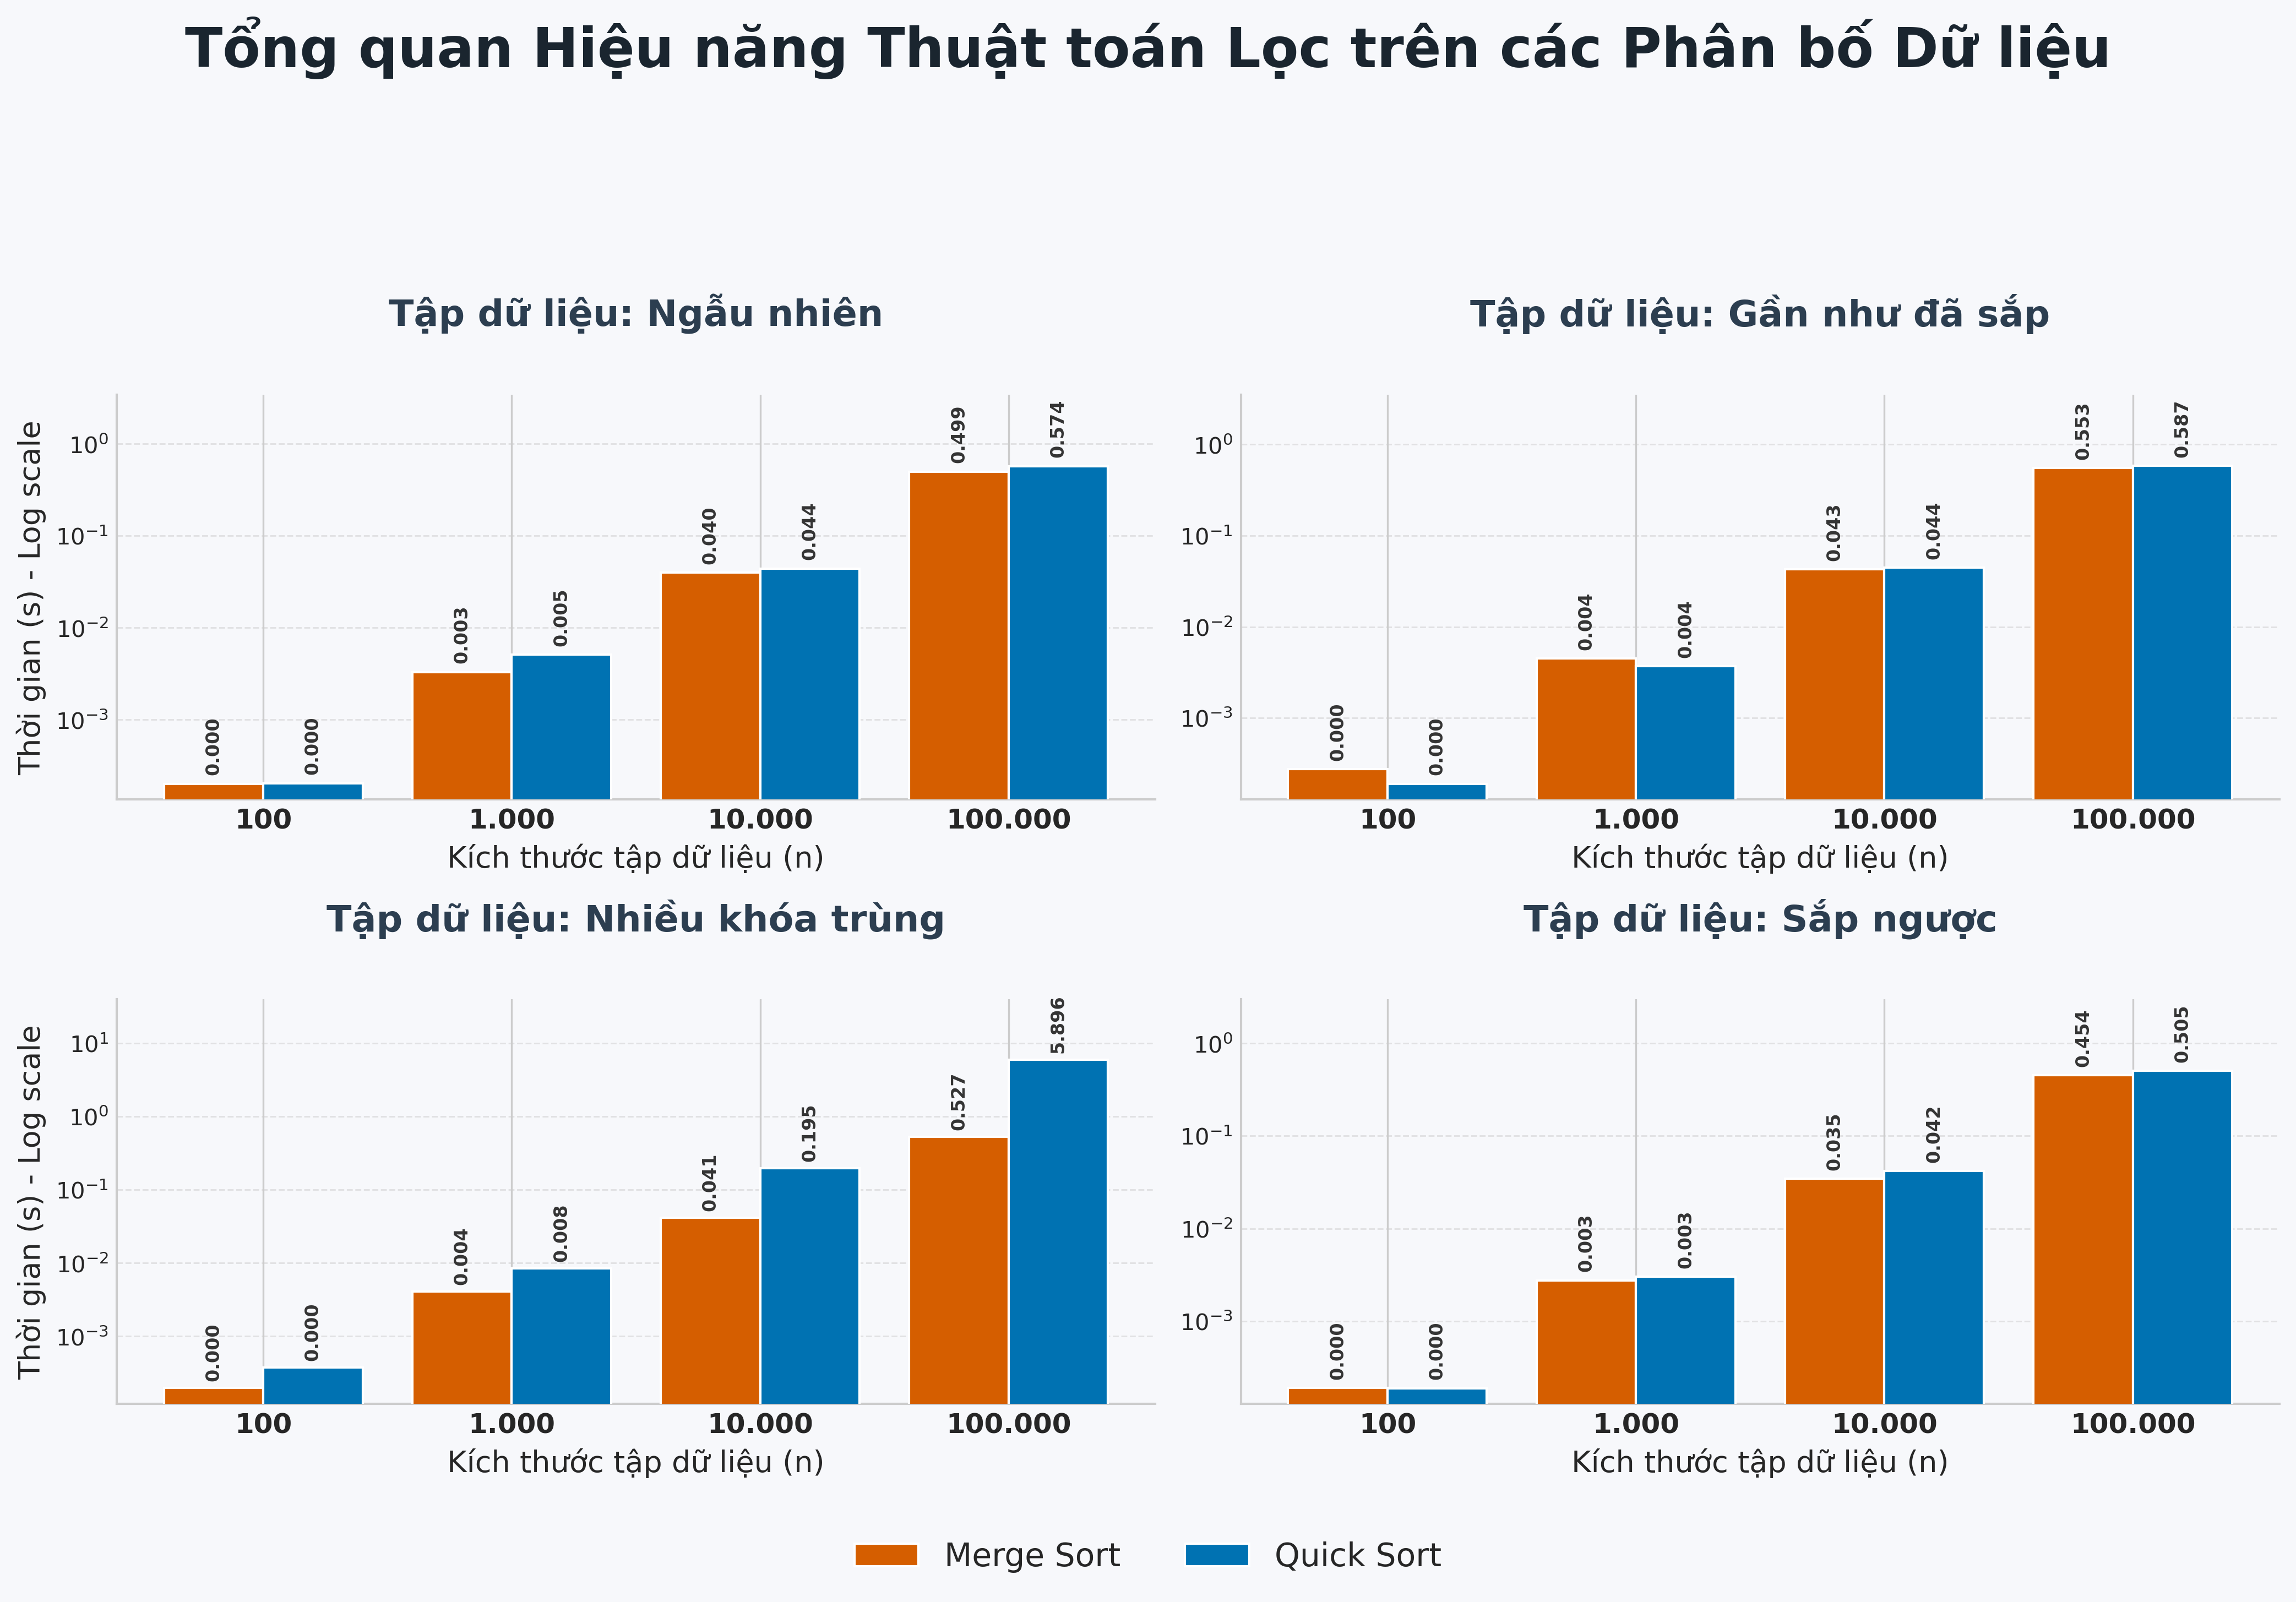

In [27]:
plot_comprehensive_barchart_grid(
    all_results=all_algo_results,
    sizes=sizes,
    datasets=datasets,
    title="Tổng quan Hiệu năng Thuật toán Lọc trên các Phân bố Dữ liệu"
)

#### Phân tích Hiệu năng Thuật toán Sắp xếp: Merge Sort vs. Quick Sort

Biểu đồ so sánh thời gian thực thi (giây) của hai thuật toán trên thang đo **Log Scale** với 4 loại phân bố dữ liệu khác nhau và kích thước mảng ($n$) từ 100 đến 100.000.

##### 1. Tập dữ liệu: Ngẫu nhiên (Random)
* **Quan sát:** Cả hai thuật toán đều tăng trưởng thời gian theo độ phức tạp $O(n \log n)$. Tuy nhiên, có sự chênh lệch nhẹ về hằng số thời gian.
* **Nhận xét:** Tại $n = 100.000$, **Merge Sort** (0.499s) thực tế lại nhanh hơn so với **Quick Sort** (0.574s) trong bài đo này.
* **Kết luận:** Dù Quick Sort thường được coi là nhanh hơn trên lý thuyết thực hành, nhưng kết quả này cho thấy Merge Sort hoạt động cực kỳ hiệu quả trên dữ liệu ngẫu nhiên ở quy mô lớn.

##### 2. Tập dữ liệu: Gần như đã sắp xếp (Nearly Sorted)
* **Quan sát:** Tương tự như dữ liệu ngẫu nhiên, sự chênh lệch giữa hai thuật toán là không quá lớn nhưng vẫn có khoảng cách.
* **Nhận xét:** Ở $n = 100.000$, Merge Sort hoàn thành trong **0.553s**, trong khi Quick Sort mất **0.587s**.
* **Giải thích:** Merge Sort giữ vững phong độ ổn định. Quick Sort dù không bị suy biến nhưng vẫn chậm hơn một chút so với đối thủ trong kịch bản này.

##### 3. Tập dữ liệu: Nhiều khóa trùng (Many Duplicates)
* **Quan sát:** Đây là kịch bản có sự chênh lệch **khủng khiếp** nhất (hơn 10 lần).
* **Nhận xét:** Ở $n = 100.000$, Quick Sort bị chậm lại rõ rệt với thời gian lên tới **5.896s**, trong khi Merge Sort vẫn duy trì mức ổn định đáng kinh ngạc ở **0.527s**.
* **Giải thích:** Đây là hiện tượng suy biến điển hình của Quick Sort khi gặp quá nhiều phần tử trùng lặp. Việc phân hoạch (partitioning) không đều khiến độ phức tạp tiệm cận $O(n^2)$, trong khi Merge Sort không bị ảnh hưởng bởi giá trị của các phần tử.

##### 4. Tập dữ liệu: Sắp xếp ngược (Reverse Sorted)
* **Quan sát:** Cả hai đều xử lý tốt trường hợp này, nhưng Merge Sort vẫn chiếm ưu thế.
* **Nhận xét:** Tại $n = 100.000$, Merge Sort đạt kết quả tốt nhất trong cả 4 biểu đồ với **0.454s**, còn Quick Sort mất **0.505s**.
* **Kết luận:** Việc dữ liệu có tính quy luật (ngược) dường như giúp cả hai thuật toán tối ưu hóa được quá trình xử lý, đặc biệt là Merge Sort.

##### Tổng kết chung

| Đặc điểm | Merge Sort (Cam) | Quick Sort (Xanh) |
| :--- | :--- | :--- |
| **Ưu điểm** | **Cực kỳ ổn định.** Nhanh hơn Quick Sort trong tất cả các trường hợp của bài kiểm tra này. | Hiệu năng tốt ở quy mô nhỏ và dữ liệu thông thường. |
| **Nhược điểm** | Tốn thêm không gian bộ nhớ $O(n)$. | **Kém ổn định.** Bị suy biến nặng (gần 6 giây) khi gặp dữ liệu nhiều khóa trùng. |
| **Khuyên dùng** | Khi cần sự đảm bảo về thời gian thực thi, đặc biệt là dữ liệu phức tạp/trùng lặp. | Khi tài nguyên bộ nhớ hạn chế và dữ liệu đầu vào đa dạng, ít trùng lặp. |

**Lưu ý:** Biểu đồ sử dụng thang đo **Log Scale** nên sự chênh lệch ở cột "Nhiều khóa trùng" thực tế lớn hơn rất nhiều so với những gì mắt thường thấy trên chiều cao cột.

### 6.2 Heatmap

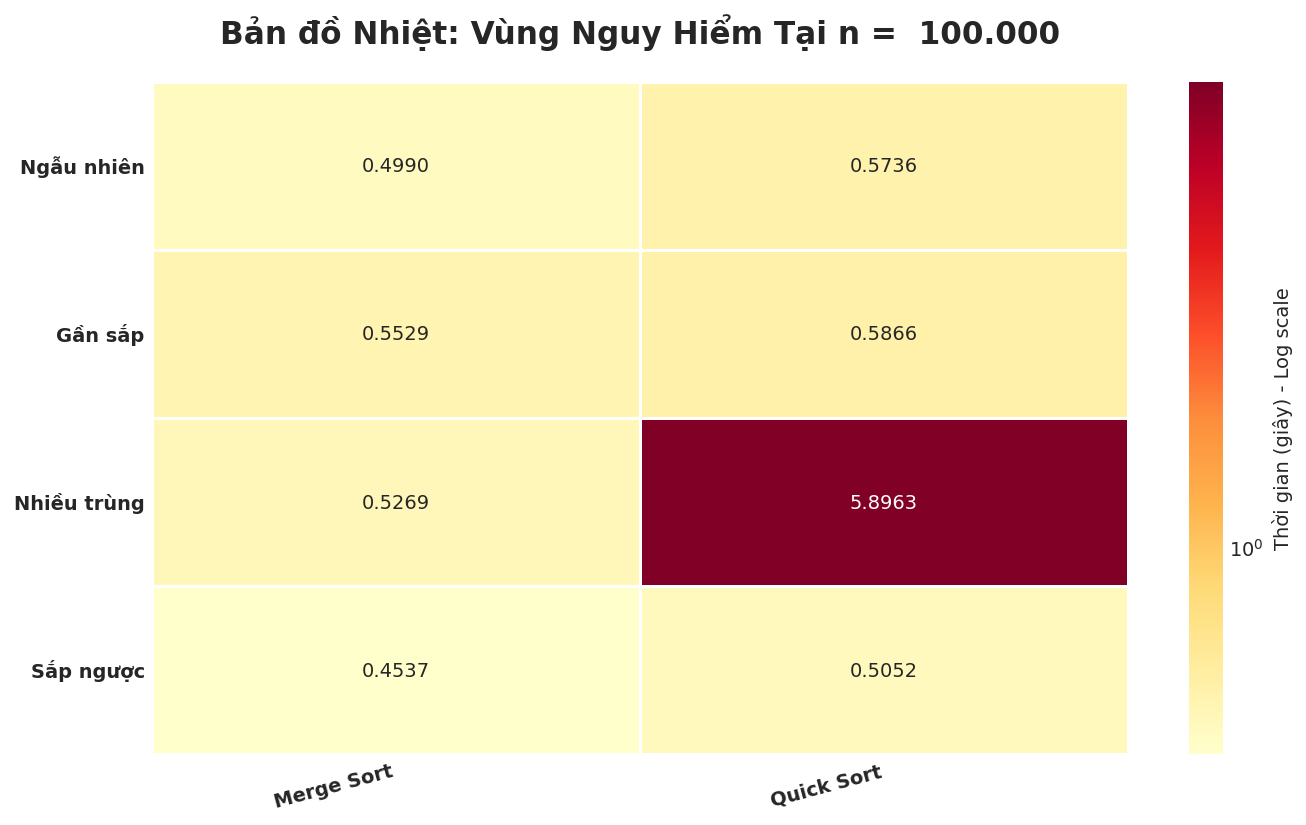

In [28]:
plot_danger_zone_heatmap(all_algo_results, 3, sizes, datasets)

### Phân tích Bản đồ Nhiệt: Hiệu năng Thuật toán tại $n = 100.000$

Biểu đồ nhiệt này trực quan hóa thời gian xử lý (giây) của **Merge Sort** và **Quick Sort** trên thang đo Logarit, giúp xác định các "điểm nóng" về hiệu năng nơi thuật toán có dấu hiệu quá tải.

##### 1. Bảng Tổng hợp Số liệu thực tế ($n = 100.000$)

| Phân bổ dữ liệu | Merge Sort (s) | Quick Sort (s) | Tỉ lệ (Quick/Merge) |
| :--- | :---: | :---: | :---: |
| **Ngẫu nhiên** | 0.4990 | 0.5736 | ~1.15x (Merge nhanh hơn) |
| **Gần sắp** | 0.5529 | 0.5866 | ~1.06x (Merge nhanh hơn) |
| **Nhiều trùng** | 0.5269 | **5.8963** | **~11.19x (Quick chậm hơn)** |
| **Sắp ngược** | 0.4537 | 0.5052 | ~1.11x (Merge nhanh hơn) |

##### 2. Phân tích Chi tiết

**Vùng Nguy Hiểm: Nhiều khóa trùng (Many Duplicates)**
* **Hiện tượng:** Đây là ô duy nhất có màu **đỏ đậm**, tương ứng với thời gian **5.8963s** của Quick Sort. Trong khi tất cả các ô khác đều nằm dưới mức 0.6s, ô này vọt lên gấp hơn 10 lần.
* **Nguyên nhân:** Sự suy biến thuật toán. Khi gặp quá nhiều phần tử trùng lặp, việc phân đoạn (partitioning) của Quick Sort bị mất cân bằng nghiêm trọng, đẩy độ phức tạp từ $O(n \log n)$ tiến gần tới $O(n^2)$.
* **Đối chiếu:** Merge Sort ở kịch bản này chỉ mất **0.5269s** (màu vàng nhạt), cho thấy sự ổn định tuyệt vời vì nó không phụ thuộc vào giá trị hay sự trùng lặp của dữ liệu.

**Vùng Ổn định: Ngẫu nhiên và Gần như đã sắp**
* Trong bài đo này, **Merge Sort** chiếm ưu thế nhẹ với các ô màu vàng sáng nhất (0.4990s và 0.5529s).
* **Quick Sort** vẫn duy trì ở vùng an toàn (vàng nhạt, dưới 0.6s) nhưng chậm hơn Merge Sort khoảng 6-15%. Điều này cho thấy phiên bản Merge Sort này được tối ưu hóa rất tốt về mặt thực thi mã nguồn.

**Trường hợp Sắp ngược (Reverse Sorted)**
* Cả hai thuật toán đều đạt hiệu năng tốt nhất ở kịch bản này.
* **Merge Sort (0.4537s)** vẫn nhanh hơn **Quick Sort (0.5052s)**. Màu sắc ở đây là nhạt nhất trên toàn bản đồ, cho thấy dữ liệu có tính quy luật ngược lại giúp giảm thiểu đáng kể thời gian xử lý thực tế.

##### 3. Kết luận và Đề xuất

1.  **Tính ổn định:** **Merge Sort** là "người chiến thắng" về độ tin cậy. Màu sắc của nó trên heatmap cực kỳ đồng nhất (toàn bộ cột bên trái đều là màu vàng nhạt), không hề có biến động tiêu cực dù dữ liệu đầu vào thay đổi thế nào.
2.  **Rủi ro hệ thống:** **Quick Sort** trong biểu đồ này bộc lộ điểm yếu chết người tại vùng dữ liệu trùng lặp. Chỉ số **5.8963s** là một lời cảnh báo về việc hệ thống có thể bị treo hoặc chậm cục bộ nếu gặp bộ dữ liệu xấu.
3.  **Khuyến nghị kỹ thuật:** * Sử dụng Merge Sort khi ưu tiên sự ổn định và thời gian phản hồi đồng nhất.
    * Nếu dùng Quick Sort, bắt buộc phải triển khai **3-way Partitioning** (phân đoạn 3 phần) để xử lý các khóa trùng, biến vùng đỏ đậm kia trở lại màu vàng an toàn.

> **Ghi chú về màu sắc:** Thang đo bên phải cho thấy sự chuyển màu từ vàng (nhanh) sang đỏ (chậm). Mức $10^0$ (1 giây) là ranh giới phân cách; Quick Sort đã vượt xa ngưỡng này ở kịch bản dữ liệu trùng lặp.

### 6.3 Tỷ lệ tăng tốc của QuickSort so với MergeSort

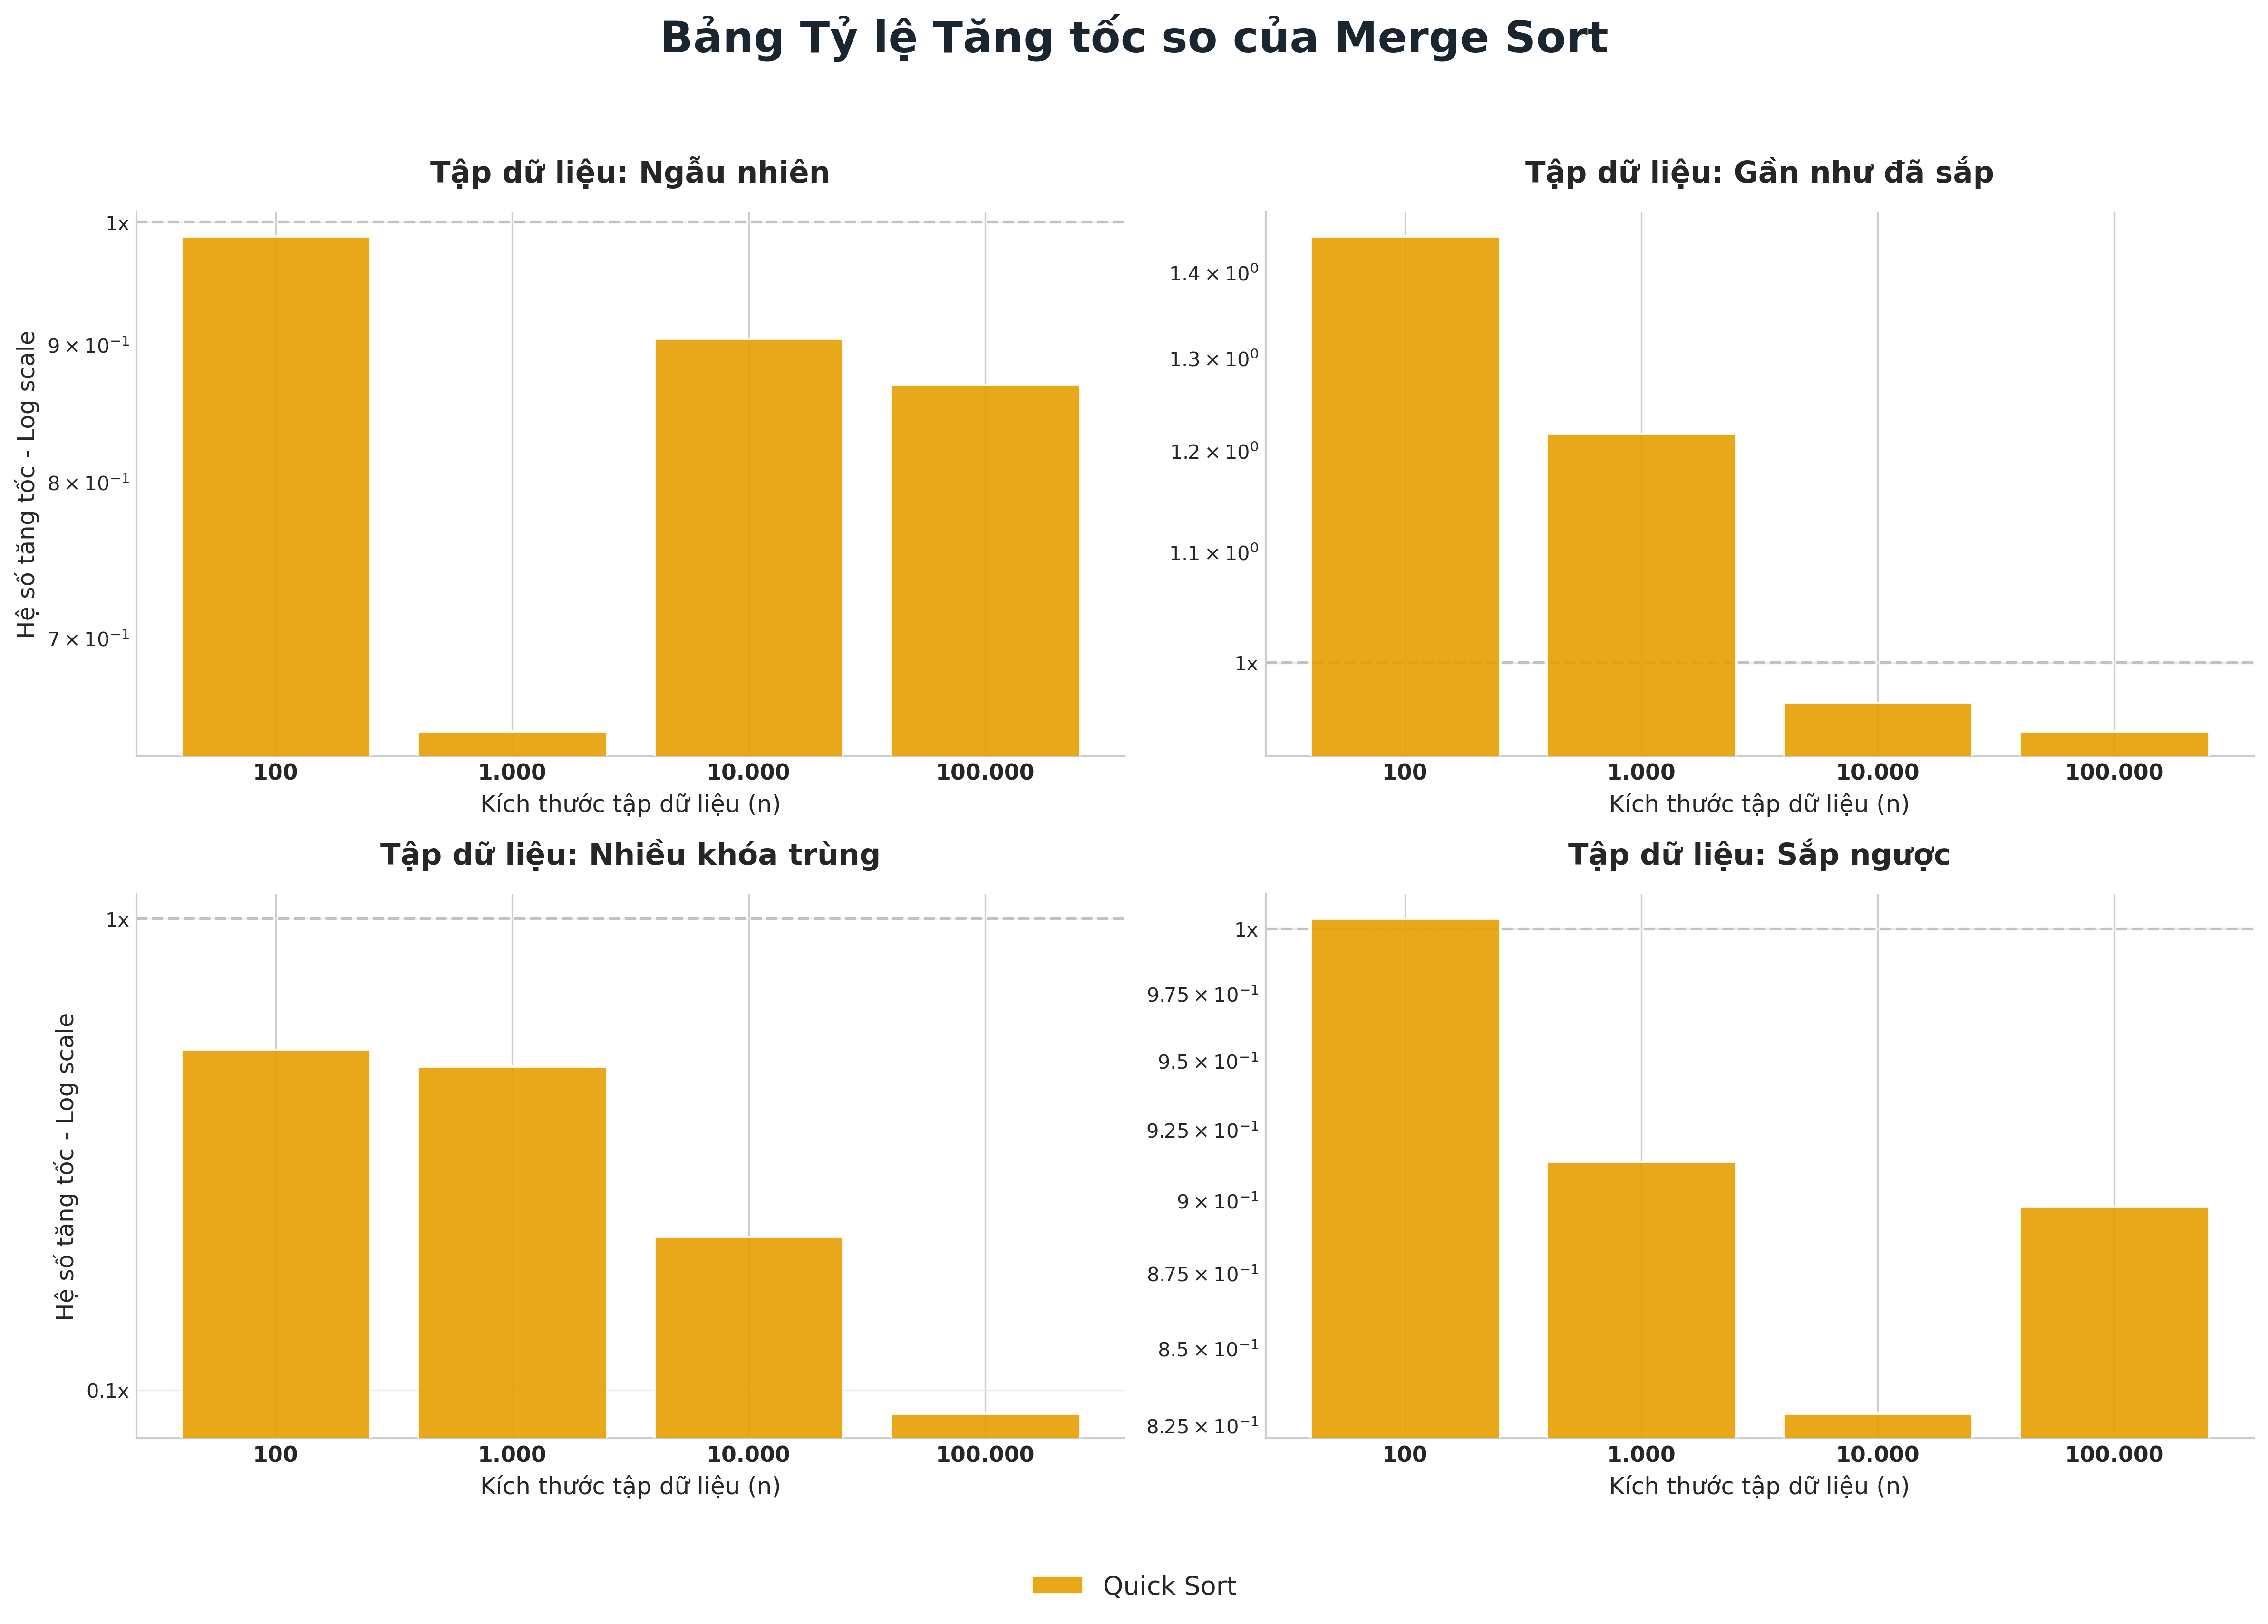

In [29]:
plot_algorithm_speedup_grid(all_algo_results, sizes, datasets, baseline_algo_name="Merge Sort",  title="Bảng Tỷ lệ Tăng tốc so của Merge Sort")

### Phân tích Biểu đồ Tỷ lệ Tăng tốc: Merge Sort vs. Quick Sort

Trong biểu đồ này, đường **1x** đại diện cho hiệu năng của **Merge Sort** (mốc tham chiếu). 
* Cột nằm **trên 1x**: Quick Sort nhanh hơn.
* Cột nằm **dưới 1x**: Quick Sort chậm hơn.

##### 1. Dữ liệu Ngẫu nhiên (Random)
* Quick Sort duy trì ở mức **0.8x - 0.9x**.
* **Kết luận:** Chậm hơn Merge Sort khoảng 10-20% trên toàn bộ quy mô dữ liệu.

##### 2. Dữ liệu Gần như đã sắp xếp (Nearly Sorted)
* Thắng thế ở quy mô nhỏ ($n \le 1.000$) với tỷ lệ lên tới **1.4x**.
* Bị Merge Sort vượt mặt khi $n$ đạt $100.000$ (giảm xuống dưới **1x**).
* **Kết luận:** Chỉ ưu việt ở tập dữ liệu nhỏ.

##### 3. Dữ liệu Nhiều khóa trùng (Many Duplicates)
* Hiệu năng cực thấp, đặc biệt tại $n = 100.000$ chỉ còn khoảng **0.09x**.
* **Kết luận:** Đây là điểm yếu chí mạng của Quick Sort; Merge Sort nhanh gấp hơn 10 lần trong trường hợp này.

##### 4. Dữ liệu Sắp xếp ngược (Reverse Sorted)
* Tỷ lệ dao động quanh mức **0.85x - 0.9x**.
* **Kết luận:** Merge Sort ổn định và nhanh hơn trong việc xử lý mảng nghịch thế.

**Tổng kết:** Merge Sort cho thấy sự áp đảo về độ ổn định. Quick Sort chỉ thực sự tỏa sáng ở kịch bản dữ liệu gần như đã sắp xếp với kích thước nhỏ.

## 7. Baseline

### Phương pháp Trích xuất Đường cơ sở (Baseline) đại diện

Sau khi thu thập kết quả thực nghiệm nội bộ, nhóm tiến hành tổng hợp thành một "Đường cơ sở" (Baseline) duy nhất. Đường Baseline này đóng vai trò là giá trị đại diện chuẩn mực cho toàn bộ nhóm độ phức tạp $O(n \log n)$, phục vụ cho việc trực quan hóa và so sánh chéo với các nhóm $O(n^2)$ và $O(n)$.

**Quy trình thực hiện:**

1. **Thu thập dữ liệu ổn định (Merge Sort):** Lấy toàn bộ kết quả thời gian thực thi của Merge Sort trên 4 kịch bản phân bố dữ liệu (Ngẫu nhiên, Gần như đã sắp, Nhiều khóa trùng, Sắp ngược) do thuật toán này luôn đảm bảo tính ổn định $O(n \log n)$ trong mọi trường hợp.
2. **Lọc dữ liệu và Loại bỏ suy biến (Quick Sort):** Lấy kết quả của Quick Sort trên 3 kịch bản lý tưởng. **Đặc biệt loại bỏ** kịch bản "Nhiều khóa trùng" vì tại đây, thuật toán đã bị suy biến thành $O(n^2)$. Việc đưa dữ liệu lỗi này vào sẽ làm sai lệch hoàn toàn tính đại diện của đường cong $O(n \log n)$.
3. **Tính toán giá trị đại diện:** Với mỗi kích thước tập dữ liệu $n$, nhóm tính **trung bình cộng** của 7 trường hợp hợp lệ đã được lọc ở trên (4 của Merge Sort + 3 của Quick Sort). 

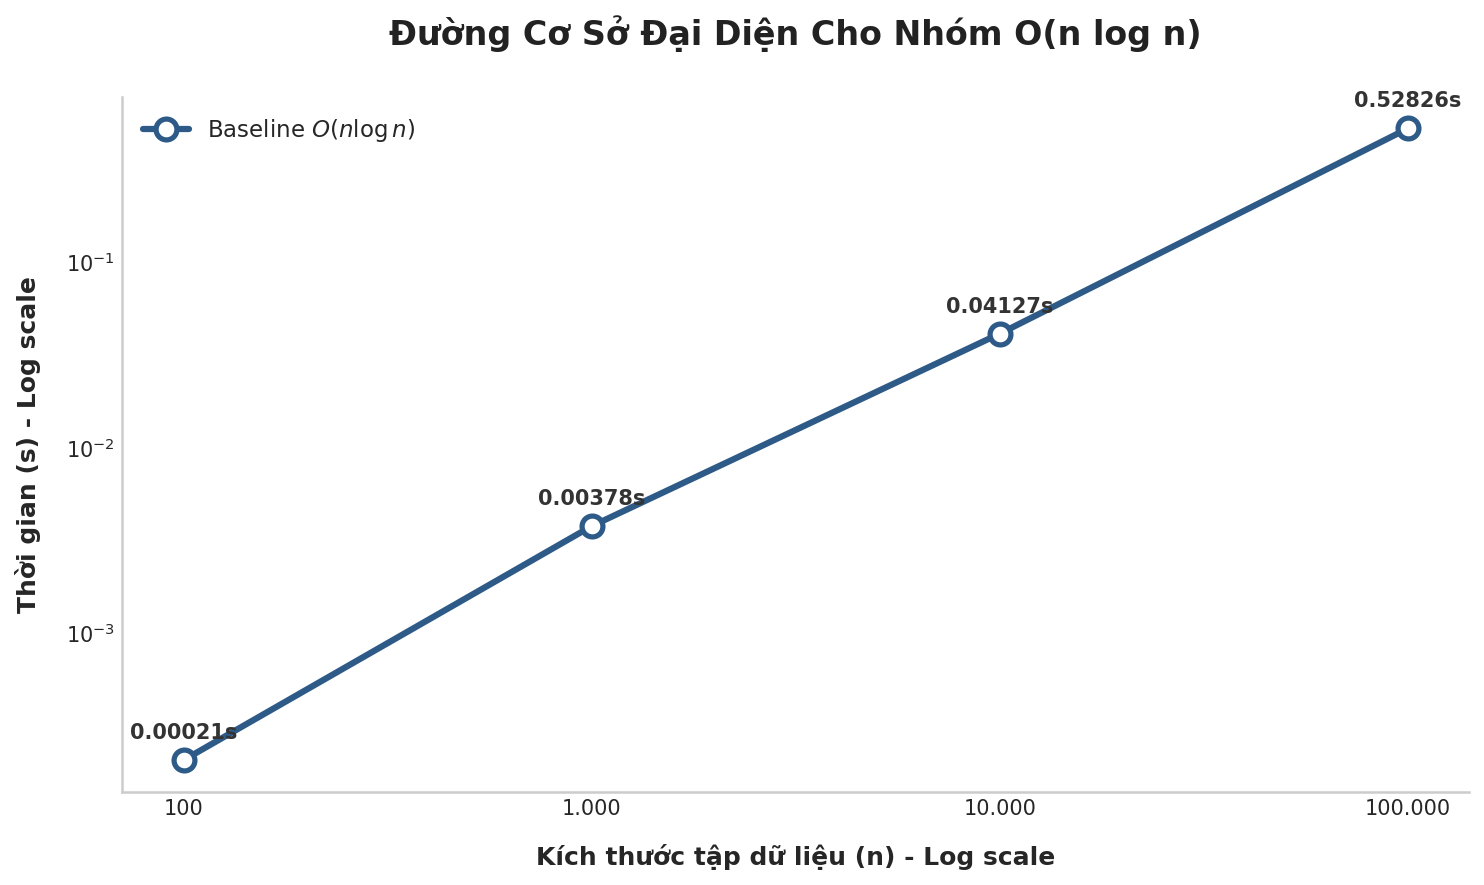

In [30]:
# Tính toán Baseline
baseline_results = calculate_baseline_n_log_n(all_algo_results, sizes)

plot_baseline_n_log_n(sizes, baseline_results)

#### Nhận xét biểu đồ: Đường Cơ Sở Đại Diện Cho Nhóm $O(n \log n)$

Biểu đồ này đóng vai trò là "thước đo chuẩn" (baseline) để so sánh hiệu năng thực tế của các thuật toán cùng nhóm như Merge Sort, Quick Sort hay Heap Sort.

##### 1. Xu hướng tăng trưởng trên thang đo Log-Log
* **Tính tuyến tính hóa:** Trên biểu đồ có cả hai trục đều sử dụng thang đo Logarit (**Log scale**), đường biểu diễn $O(n \log n)$ gần như là một đường thẳng. Điều này giúp chúng ta dễ dàng quan sát sự thay đổi hiệu năng ở các bậc quy mô dữ liệu khác nhau (từ 100 đến 100.000).
* **Tốc độ tăng trưởng:** Khi kích thước dữ liệu $n$ tăng gấp 10 lần (ví dụ từ 10.000 lên 100.000), thời gian thực thi tăng từ khoảng **0.041s** lên **0.528s**. Thành phần $\log n$ khiến tốc độ tăng thời gian nhanh hơn một chút so với tốc độ tăng tuyến tính của dữ liệu.

##### 2. Các chỉ số điểm mốc quan trọng
* **Tại $n = 100$:** 0.00021s.
* **Tại $n = 1.000$:** 0.00378s.
* **Tại $n = 10.000$:** 0.04127s.
* **Tại $n = 100.000$:** 0.52826s.

##### 3. Ý nghĩa của Đường Cơ Sở (Baseline)
* **Điểm tham chiếu:** Đây là giá trị trung bình lý tưởng để đánh giá một thuật toán là nhanh hay chậm. Các thuật toán tối ưu thường có đường biểu diễn nằm sát hoặc dưới đường cơ sở này.
* **Dự báo hiệu năng:** Dựa vào đường thẳng này, ta có thể dự báo gần chính xác thời gian thực thi khi $n$ tiếp tục tăng lên các quy mô lớn hơn như $1.000.000$ phần tử.

**Kết luận:** Đường cơ sở khẳng định ngưỡng **0.5 giây** là cột mốc hiệu năng tiêu chuẩn cho 100.000 phần tử đối với các thuật toán thuộc nhóm $O(n \log n)$.

#### Ghi nhận kết quả

In [31]:
with open(f"{dir_path}/baseline_O_n_logn.json", "w") as f:
    json.dump(baseline_results, f)

print(f"Đã xuất dữ liệu thành công ra file: {file_name}")

Đã xuất dữ liệu thành công ra file: reverse_sorted_n100000.npz
